# IMPORT LIABIRIAYS

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, PolynomialFeatures, LabelEncoder)
from sklearn.decomposition import PCA
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, KFold)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,GradientBoostingClassifier, GradientBoostingRegressor)
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,ConfusionMatrixDisplay, classification_report,
r2_score, mean_squared_error, mean_absolute_error)
import joblib
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")

Libraries imported successfully.


# LOAD DATA

In [2]:
census_raw = pd.read_csv('census_income.csv')
car_raw = pd.read_csv('data.csv')

In [3]:
print("CENSUS INCOME DATASET")
census_raw.shape


CENSUS INCOME DATASET


(47573, 15)

In [4]:
print("CENSUS INCOME DATASET")
census_raw.info()

CENSUS INCOME DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47573 entries, 0 to 47572
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             47573 non-null  int64 
 1   workclass       47573 non-null  object
 2   fnlwgt          47573 non-null  int64 
 3   education       47573 non-null  object
 4   education-num   47573 non-null  int64 
 5   marital-status  47573 non-null  object
 6   occupation      47573 non-null  object
 7   relationship    47573 non-null  object
 8   race            47573 non-null  object
 9   sex             47573 non-null  object
 10  capital-gain    47573 non-null  int64 
 11  capital-loss    47573 non-null  int64 
 12  hours-per-week  47573 non-null  int64 
 13  native-country  47573 non-null  object
 14  income          47573 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 5.4+ MB


In [5]:
display(census_raw.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [6]:
census_raw.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,47573.000000,4.757300e+04,47573.000000,47573.000000,47573.000000,47573.000000,47573.000000
mean,38.648771,1.897319e+05,10.091628,1092.238581,87.942131,40.603998,0.242469
std,13.556990,1.055829e+05,2.567288,7490.924415,404.204740,12.261040,0.428581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175850e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.782820e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.377130e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [7]:
census_raw.duplicated().sum()

np.int64(0)

In [8]:
print("CAR LISTINGS DATASET")
car_raw.shape

CAR LISTINGS DATASET


(20461, 11)

In [9]:
car_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20461 entries, 0 to 20460
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        20461 non-null  float64
 1   brand        20461 non-null  object 
 2   model        20461 non-null  object 
 3   year         20461 non-null  object 
 4   condition    20461 non-null  object 
 5   kilo_meter   20461 non-null  object 
 6   color        20461 non-null  object 
 7   power_trans  20461 non-null  object 
 8   fuel_type    20461 non-null  object 
 9   location     20461 non-null  object 
 10  price_bin    20461 non-null  float64
dtypes: float64(2), object(9)
memory usage: 1.7+ MB


In [10]:
car_raw.head()

,price,brand,model,year,condition,kilo_meter,color,power_trans,fuel_type,location,price_bin
0,2000000.0,Cadillac,Escalade,2018,Used,"185,000 KM",Black,Automatic,Diesel,Tagamo3 - New Cairo,0.7
1,2000000.0,Seat,Tarraco,2024,Used,"45,000 KM",Black,Automatic,Gas,Cairo,0.7
2,1050000.0,Toyota,Corolla,2020,Used,"44,000 KM",White,Automatic,Gas,Nasr city,0.3
3,1120000.0,Skoda,Octavia,2020,Used,"125,000 KM",Gray,Automatic,Gas,Nasr city,0.4
4,1020000.0,Hyundai,Elantra,2027,New,0 KM,Dark blue,Automatic,Gas,Mohandessin,0.3


In [11]:
car_raw.tail()

,price,brand,model,year,condition,kilo_meter,color,power_trans,fuel_type,location,price_bin
20456,1385000.0,Toyota,Corolla,2025,Used,"10,000",Gray,Automatic,Benzine,Giza,0.5
20457,620000.0,Kia,Rio,2017,Used,"135,000",Brown,Automatic,Benzine,Nasr City,0.2
20458,1795000.0,Deepal,S07,2024,New,0,Gray,Automatic,Electric,Cairo,0.6
20459,770000.0,Chrysler,Town and Country,2010,Used,"300,000",Gray,Automatic,Benzine,Cairo,0.2
20460,1750000.0,Mercedes-Benz,C180,2018,Used,"128,000",White,Automatic,Benzine,Cairo,0.6


In [12]:
car_raw.describe()

,price,price_bin
count,2.046100e+04,20461.000000
mean,8.404031e+05,0.262724
std,6.133259e+05,0.229443
min,1.000000e+03,0.000000
25%,3.500000e+05,0.100000
50%,6.900000e+05,0.200000
75%,1.180000e+06,0.400000
max,2.690000e+06,0.900000


In [13]:
car_raw.duplicated().sum()

np.int64(0)

# Data Cleaning & Exploratory Data Analysis (EDA)

## 3.1  Clean the CENSUS dataset

In [14]:
census = census_raw.copy()
census.columns = [c.strip() for c in census.columns]

In [15]:
str_cols = census.select_dtypes(include=['object', 'string']).columns
for c in str_cols:
    census[c] = census[c].astype(str).str.strip()

In [17]:
census['income'] = census['income'].str.replace('.', '', regex=False)

AttributeError: Can only use .str accessor with string values!

In [18]:
census.replace('?', np.nan, inplace=True)

In [19]:
n_before = len(census)
census.drop_duplicates(inplace=True)
print(f"Census: dropped {n_before - len(census)} duplicate rows -> {census.shape}")


Census: dropped 0 duplicate rows -> (47573, 15)


In [20]:
print("\nMissing values per column:")
print(census.isnull().sum()[census.isnull().sum() > 0])



Missing values per column:
workclass         1836
occupation        1843
native-country     582
dtype: int64


In [21]:
print("\nIncome label distribution:")
print(census['income'].value_counts())


Income label distribution:
income
0    36038
1    11535
Name: count, dtype: int64


## 3.2  EDA — Census dataset

Text(0.5, 1.0, 'Income Label Distribution')

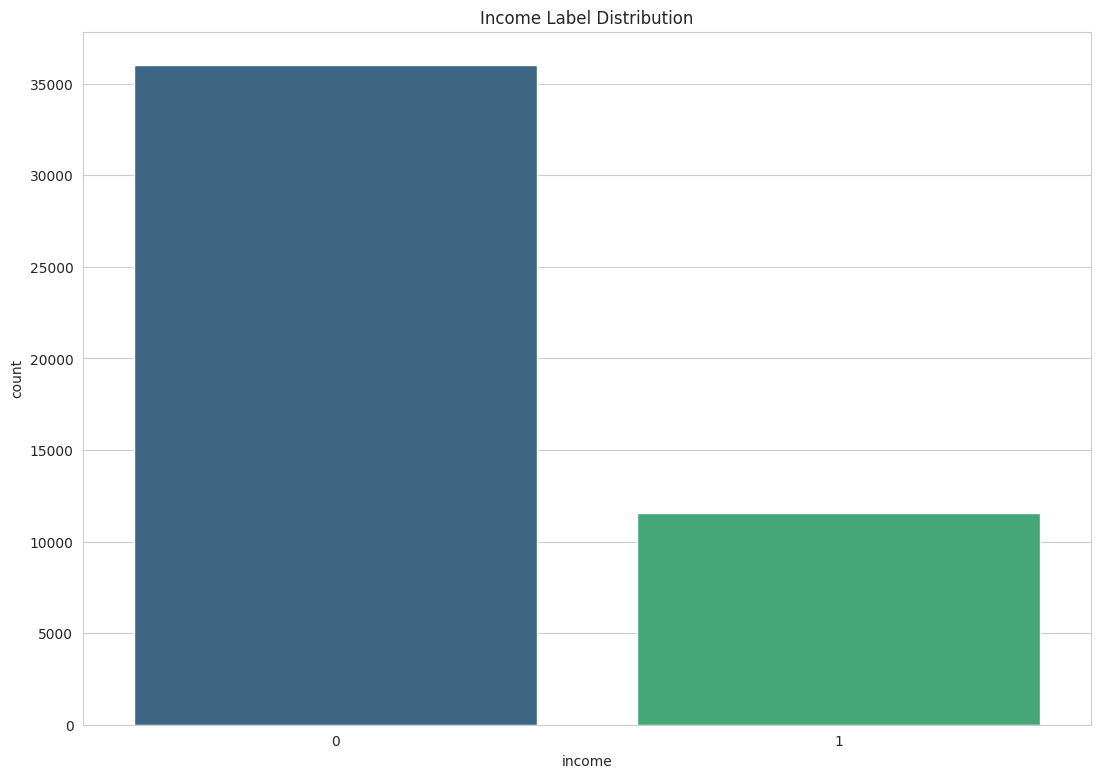

In [22]:
fig, axes = plt.subplots(figsize=(13, 9))

sns.countplot(data=census, x='income', hue='income', palette='viridis', legend=False)
axes.set_title('Income Label Distribution')

Text(0.5, 1.0, 'Age Distribution')

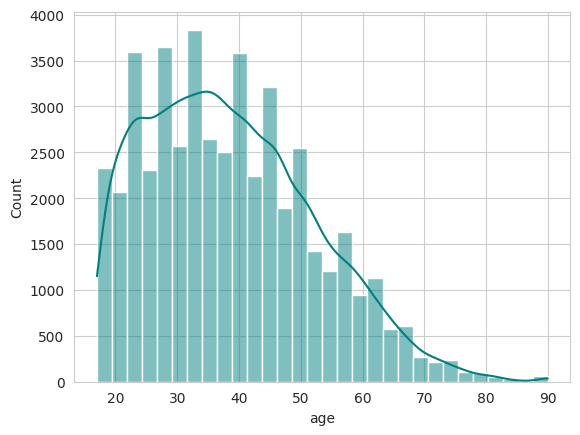

In [23]:
sns.histplot(census['age'], bins=30, kde=True, color='teal')
axes.set_title('Age Distribution')


Text(0.5, 1.0, 'Hours-per-Week Distribution')

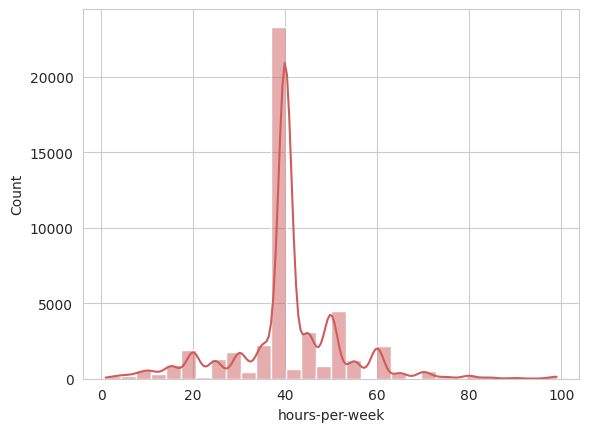

In [24]:
sns.histplot(census['hours-per-week'], bins=30, kde=True, color='indianred')
axes.set_title('Hours-per-Week Distribution')


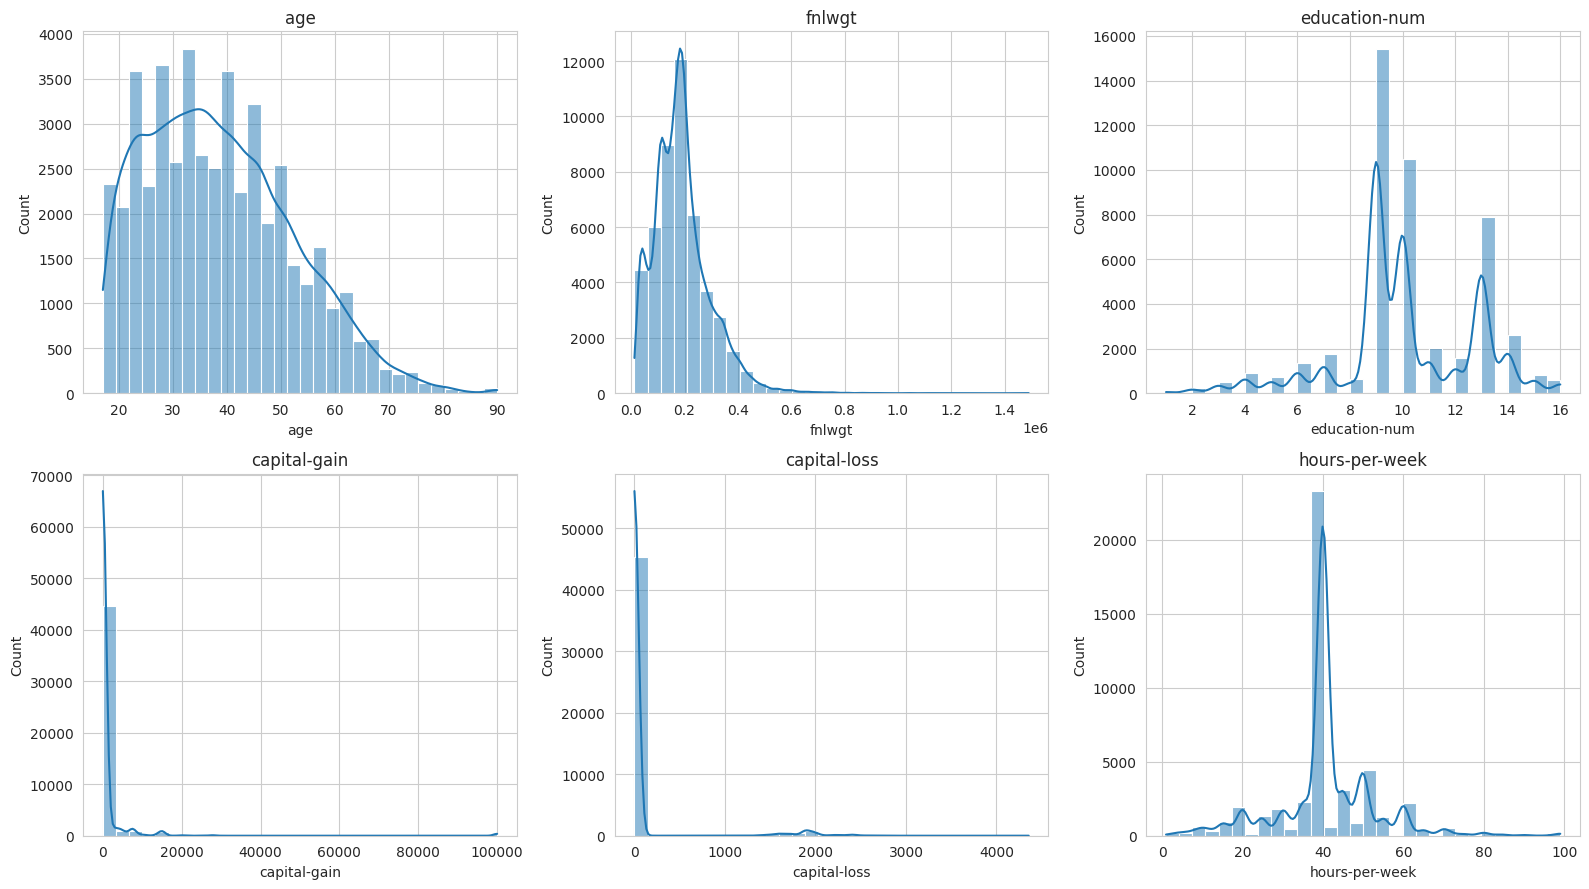

In [25]:
numeric_cols_census = census.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(2,3,figsize=(16, 9))
for ax, col in zip(axes.ravel(),numeric_cols_census):
    sns.histplot(census[col],bins=30,kde=True,ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [26]:
categorical_cols_eda = census.select_dtypes(include="object").columns.tolist()
print(categorical_cols_eda)

['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


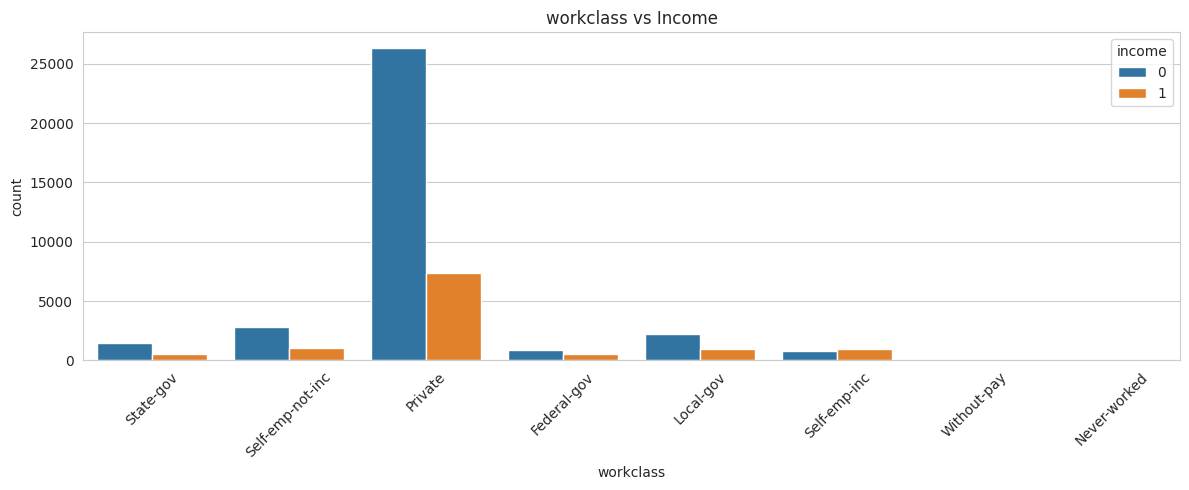

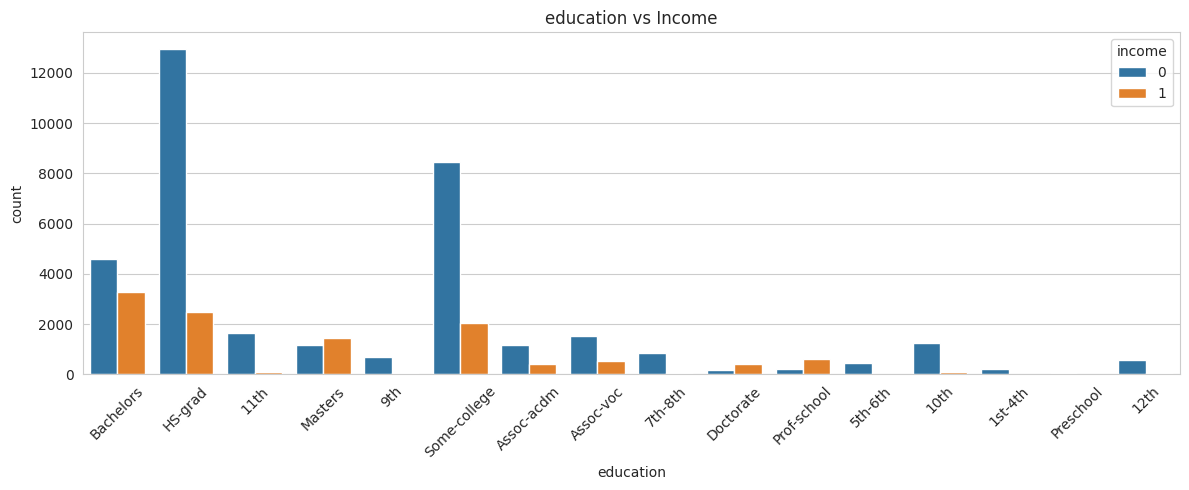

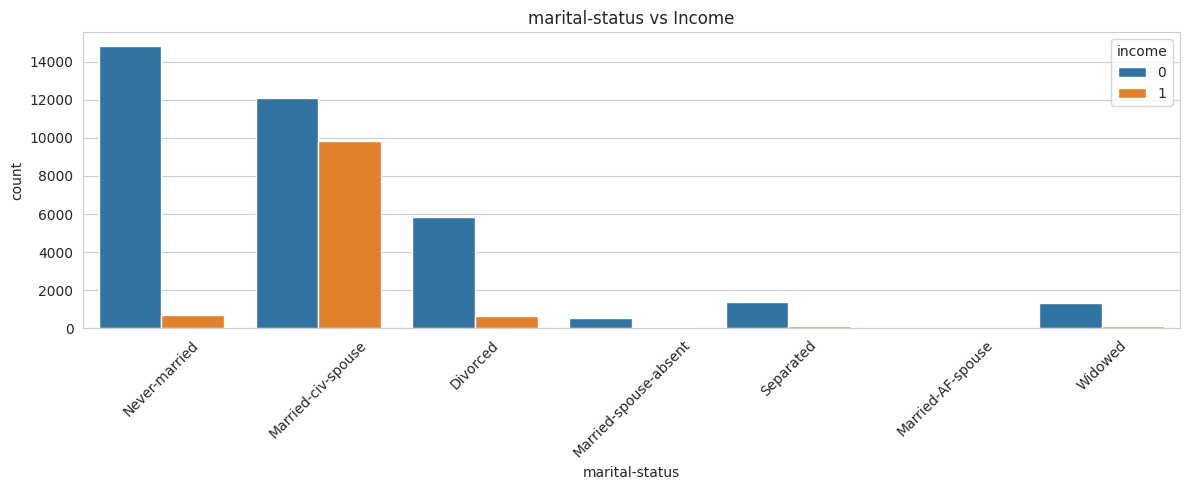

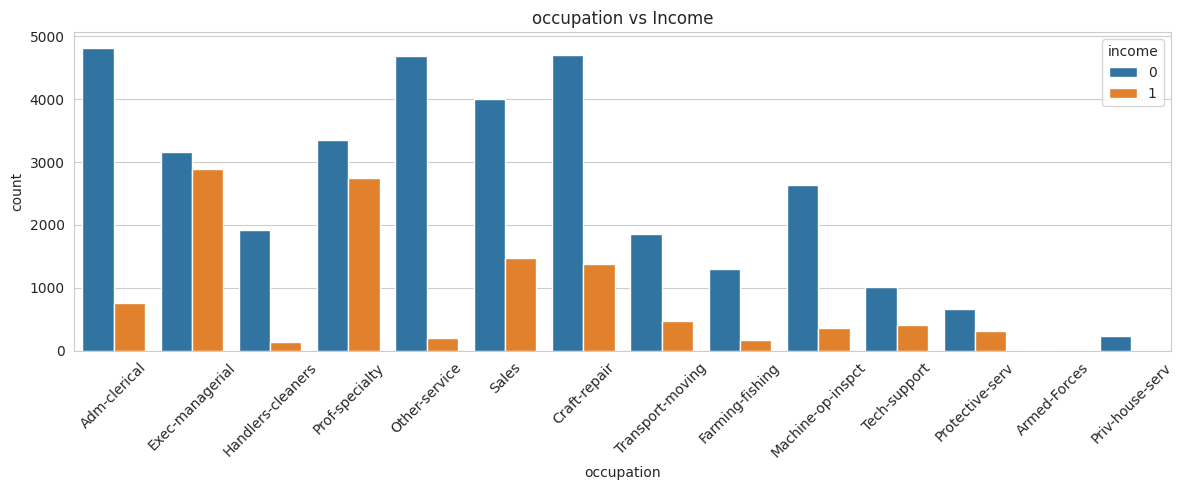

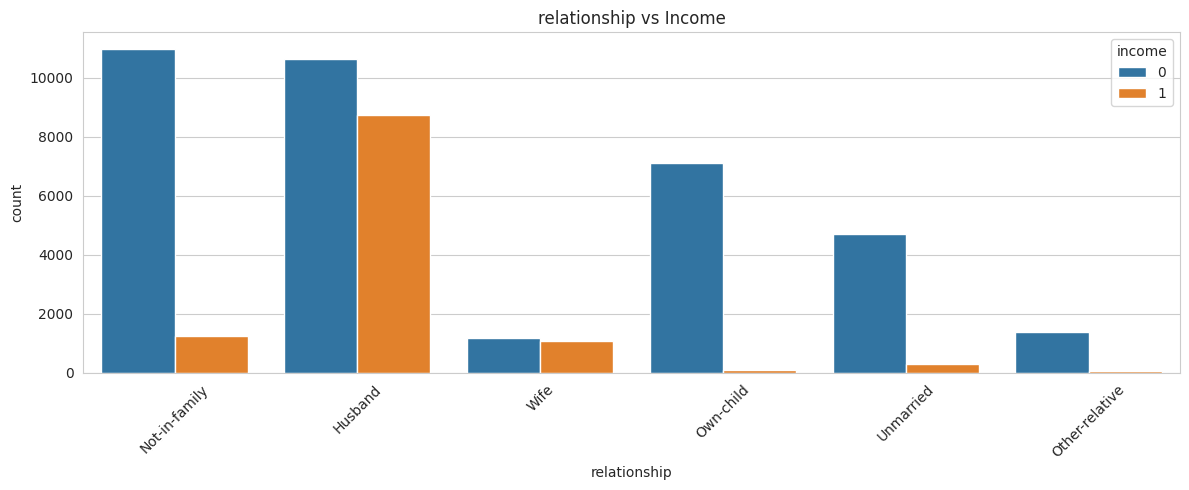

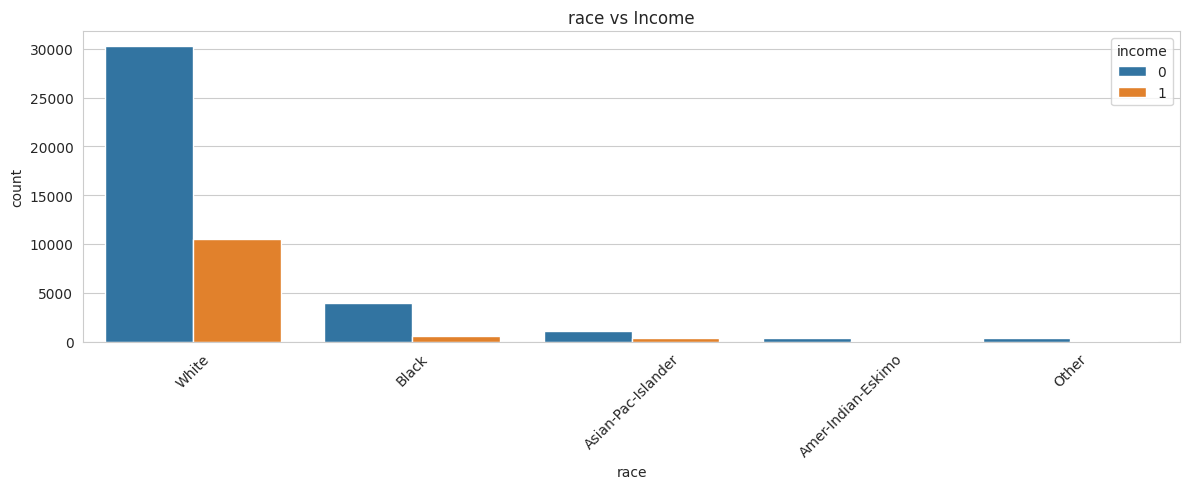

In [27]:
for col in categorical_cols_eda[:6]:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=census,x=col,hue="income")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Income")
    plt.tight_layout()
    plt.show()

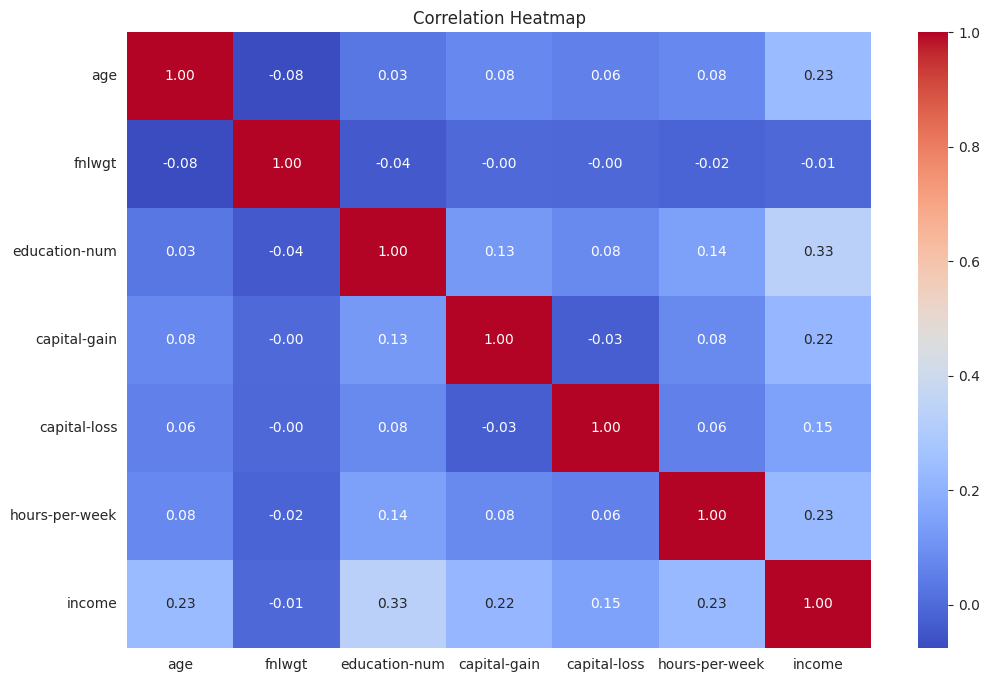

In [28]:
plt.figure(figsize=(12, 8))

sns.heatmap(census.select_dtypes(include=np.number).corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## 3.3  Clean the CAR dataset

In [29]:
car = car_raw.copy()

In [30]:
def extract_numeric(series: pd.Series) -> pd.Series:
    '''Robustly pull a numeric value out of messy strings such as
    '6,600,000', 'EGP 1,850,000', '40,000 KM', or 'Unknown'.'''
    digits = series.astype(str).str.extract(r'([\d,]+)')[0]
    return pd.to_numeric(digits.str.replace(',', '', regex=False), errors='coerce')
car['price'] = extract_numeric(car['price'])
car['kilo_meter'] = extract_numeric(car['kilo_meter'])
car['year'] = pd.to_numeric(car['year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')


In [31]:
cat_cols = ['brand', 'model', 'condition', 'color', 'power_trans', 'fuel_type', 'location']

In [32]:
for c in cat_cols:
    car[c] = car[c].astype(str).str.strip().replace({'Unknown': np.nan, 'nan': np.nan})

n_before = len(car)
car.drop_duplicates(inplace=True)
print(f"Car data: dropped {n_before - len(car)} duplicate rows")

Car data: dropped 7 duplicate rows


In [33]:
n_before = len(car)
car.dropna(subset=['price', 'year', 'kilo_meter'], inplace=True)
print(f"Car data: dropped {n_before - len(car)} rows with unparseable price/year/kilo_meter")


Car data: dropped 13 rows with unparseable price/year/kilo_meter


In [34]:
car = car[(car['year'] >= 1980) & (car['year'] <= 2027)]
price_cap = car['price'].quantile(0.995)
n_before = len(car)
car = car[(car['price'] >= 15_000) & (car['price'] <= price_cap)]
print(f"Car data: dropped {n_before - len(car)} extreme price outliers (cap={price_cap:,.0f} EGP)")


Car data: dropped 50 extreme price outliers (cap=2,600,000 EGP)


In [35]:
print(f"\nFinal cleaned car dataset shape: {car.shape}")


Final cleaned car dataset shape: (20229, 11)


In [36]:
print("\nRemaining missing values:")
print(car.isnull().sum()[car.isnull().sum() > 0])


Remaining missing values:
location    228
dtype: int64


In [37]:
print("\nCleaned price summary:")
print(car['price'].describe())


Cleaned price summary:
count    2.022900e+04
mean     8.420590e+05
std      6.065901e+05
min      2.000000e+04
25%      3.550000e+05
50%      6.950000e+05
75%      1.180000e+06
max      2.600000e+06
Name: price, dtype: float64


## 3.4  EDA — Car dataset

Text(0.5, 0, 'Price (EGP)')

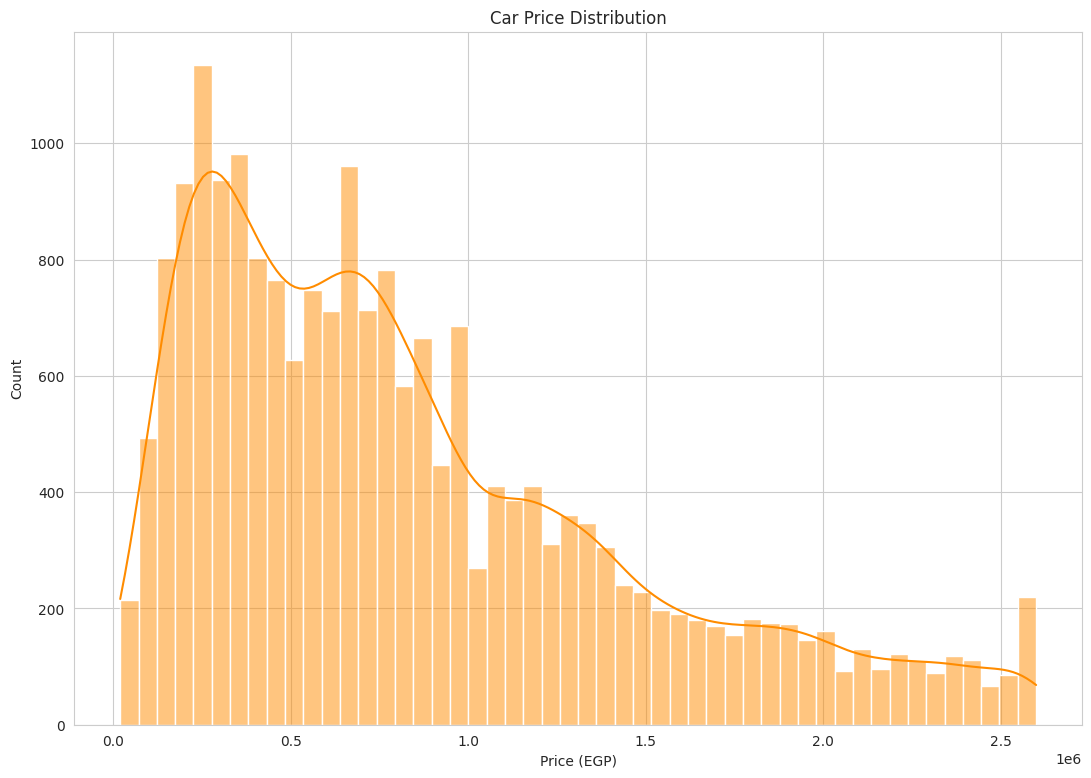

In [38]:
fig, axes = plt.subplots(figsize=(13, 9))
sns.histplot(car['price'], bins=50, kde=True, color='darkorange')
axes.set_title('Car Price Distribution')
axes.set_xlabel('Price (EGP)')


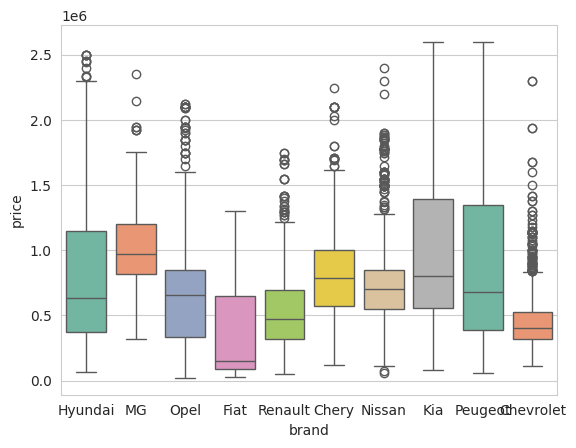

In [39]:
top_brands = car['brand'].value_counts().head(10).index
sns.boxplot(data=car[car['brand'].isin(top_brands)], x='brand', y='price', hue='brand',
            palette='Set2', legend=False)
axes.set_title('Price by Brand (Top 10 by Volume)')
axes.tick_params(axis='x', rotation=45)


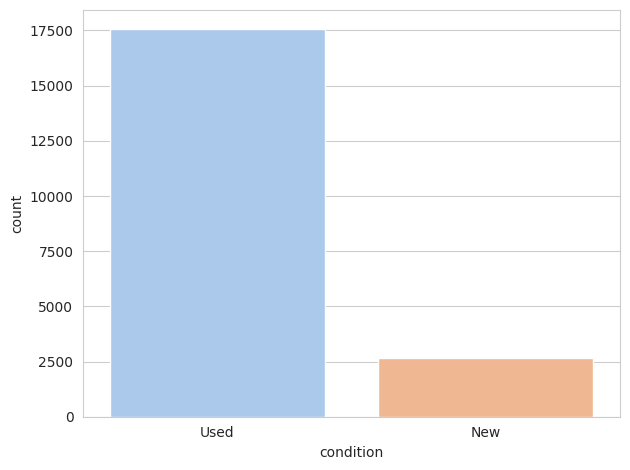

In [40]:
sns.countplot(data=car, x='condition', hue='condition', palette='pastel', legend=False)
axes.set_title('Condition Distribution')
plt.tight_layout()
plt.show()

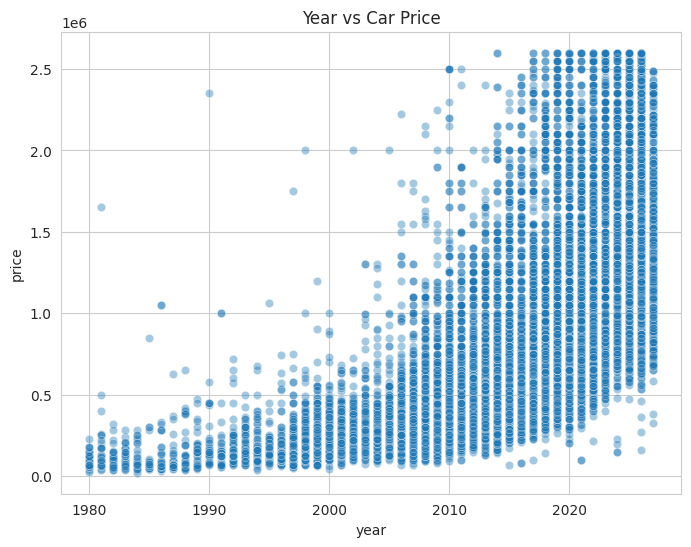

In [41]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=car,x="year",y="price",alpha=0.4)
plt.title("Year vs Car Price")
plt.show()

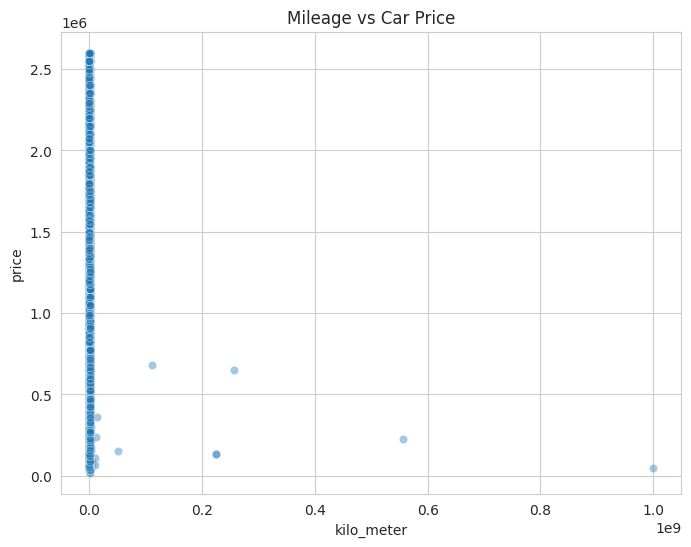

In [42]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=car,x="kilo_meter",y="price",alpha=0.4)
plt.title("Mileage vs Car Price")
plt.show()

Text(0.5, 1.0, 'Numeric Feature Correlation Heatmap')

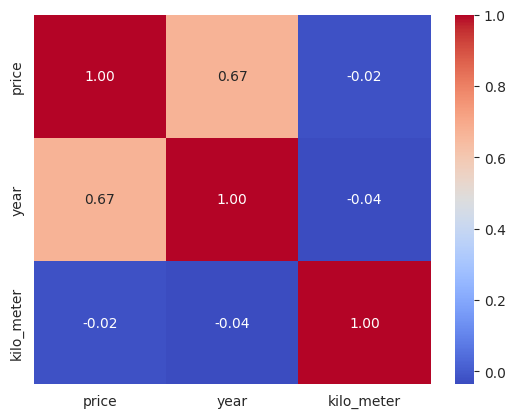

In [43]:
numeric_cols_car = ['price', 'year', 'kilo_meter']
sns.heatmap(car[numeric_cols_car].corr(), annot=True, fmt='.2f', cmap='coolwarm')
axes.set_title('Numeric Feature Correlation Heatmap')


# Feature Engineering & Target Binning

## 4.1  Engineer a 5-tier income target from the census data

In [44]:
census_fe = census.copy()

In [45]:
census_fe['income_binary'] = (census_fe['income'] == '>50K').astype(int)

In [46]:
income_score = (
    census_fe['income_binary'] * 50_000
    + census_fe['capital-gain'] * 1.0
    - census_fe['capital-loss'] * 0.5
    + census_fe['hours-per-week'] * 300
    + census_fe['education-num'] * 1_200
    + census_fe['age'] * 80
)

In [47]:
census_fe['income_bin'] = pd.qcut(income_score, q=5,
    labels=['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4', 'Bin 5'])

In [48]:
print("Income tier distribution:")
print(census_fe['income_bin'].value_counts().sort_index())

Income tier distribution:
income_bin
Bin 1    9519
Bin 2    9738
Bin 3    9287
Bin 4    9538
Bin 5    9491
Name: count, dtype: int64


In [49]:
print("\nCross-tab vs. original binary label (sanity check):")
print(pd.crosstab(census_fe['income_bin'], census_fe['income']))



Cross-tab vs. original binary label (sanity check):
income         0     1
income_bin            
Bin 1       9201   318
Bin 2       8876   862
Bin 3       7447  1840
Bin 4       6612  2926
Bin 5       3902  5589


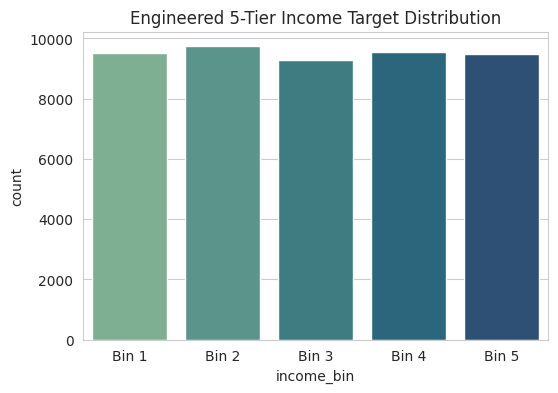

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(data=census_fe, x='income_bin', hue='income_bin', order=['Bin 1','Bin 2','Bin 3','Bin 4','Bin 5'],
    palette='crest', legend=False)
plt.title('Engineered 5-Tier Income Target Distribution')
plt.show()

## 4.2  Build X / y for the CLASSIFICATION task + train/test split

In [51]:
drop_cols = ['income', 'income_binary', 'income_bin', 'fnlwgt']
X_clf = census_fe.drop(columns=drop_cols)
y_clf = census_fe['income_bin']

In [52]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [53]:
label_encoder = LabelEncoder()
label_encoder.fit(['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4', 'Bin 5'])
y_clf_train_enc = label_encoder.transform(y_clf_train)
y_clf_test_enc = label_encoder.transform(y_clf_test)

In [54]:
print("Classification feature matrix:", X_clf.shape)
print("Train / Test split:", X_clf_train.shape, X_clf_test.shape)

Classification feature matrix: (47573, 13)
Train / Test split: (38058, 13) (9515, 13)


In [55]:
numeric_features_clf = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features_clf = [c for c in X_clf.columns if c not in numeric_features_clf]
print("Numeric features:", numeric_features_clf)
print("Categorical features:", categorical_features_clf)

Numeric features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 4.3  Build X / y for the REGRESSION task (car price) + train/test split

In [56]:
CURRENT_YEAR = 2026
car_fe = car.copy()
car_fe['car_age'] = CURRENT_YEAR - car_fe['year']

In [57]:
reg_features = ['brand', 'car_age', 'condition', 'kilo_meter', 'color','power_trans',
'fuel_type', 'location']
X_reg = car_fe[reg_features]
y_reg = car_fe['price']


In [58]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [59]:
print("Regression feature matrix:", X_reg.shape)
print("Train / Test split:", X_reg_train.shape, X_reg_test.shape)

Regression feature matrix: (20229, 8)
Train / Test split: (16183, 8) (4046, 8)


In [60]:
numeric_features_reg = ['car_age', 'kilo_meter']
print("Numeric features:", numeric_features_reg)

Numeric features: ['car_age', 'kilo_meter']


In [61]:
categorical_features_reg = ['brand', 'condition', 'color', 'power_trans', 'fuel_type', 'location']
print("Categorical features:", categorical_features_reg)

Categorical features: ['brand', 'condition', 'color', 'power_trans', 'fuel_type', 'location']


# 5.1  Reusable ColumnTransformer for the classification task

In [62]:
numeric_transformer_clf = Pipeline(steps=[
('imputer', SimpleImputer(strategy='median')),
('scaler', StandardScaler()),])

In [63]:
categorical_transformer_clf = Pipeline(steps=[
('imputer', SimpleImputer(strategy='most_frequent')),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),])

In [64]:
preprocessor_clf = ColumnTransformer(transformers=[
('num', numeric_transformer_clf, numeric_features_clf),
('cat', categorical_transformer_clf, categorical_features_clf),])

In [65]:
print("Classification ColumnTransformer ready.")
print(preprocessor_clf)

Classification ColumnTransformer ready.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education-num', 'capital-gain',
                                  'capital-loss', 'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occup

In [66]:
cv_clf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [67]:
def stratified_subsample(X, y, n, seed=RANDOM_STATE):
    if len(X) <= n:
        return X, y
    idx = np.random.RandomState(seed).choice(len(X), size=n, replace=False)
    return X.iloc[idx], np.asarray(y)[idx]


In [68]:
def tune_and_evaluate_classifier(name, pipeline, param_grid,search_sample_size=None,final_fit_sample_size=None):

    X_search, y_search = (stratified_subsample(X_clf_train, y_clf_train_enc, search_sample_size)
        if search_sample_size else (X_clf_train, y_clf_train_enc))
    grid = GridSearchCV(pipeline, param_grid, cv=cv_clf, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_search, y_search)
    best_pipeline = grid.best_estimator_
    X_fit, y_fit = (stratified_subsample(X_clf_train, y_clf_train_enc, final_fit_sample_size, seed=7)
        if final_fit_sample_size else (X_clf_train, y_clf_train_enc))
    best_pipeline.fit(X_fit, y_fit)
    y_pred = best_pipeline.predict(X_clf_test)
    y_proba = best_pipeline.predict_proba(X_clf_test) if hasattr(best_pipeline, 'predict_proba') else None
    metrics = {
        'model': name,
        'best_params': grid.best_params_,
        'accuracy': accuracy_score(y_clf_test_enc, y_pred),
        'f1_macro': f1_score(y_clf_test_enc, y_pred, average='macro'),
        'roc_auc_ovr': roc_auc_score(y_clf_test_enc, y_proba, multi_class='ovr', average='macro') if y_proba is not None else np.nan,
    }
    return best_pipeline, y_pred, metrics

In [69]:

classification_pipelines = {
'Logistic Regression': (
    Pipeline([('preprocessor', preprocessor_clf),
    ('pca', PCA(n_components=0.95, svd_solver='full', random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),]),
    {'classifier__C': [0.1, 1, 10]},{},),

    'Naive Bayes': (
        Pipeline([
    ('preprocessor', preprocessor_clf),
    ('classifier', GaussianNB()),]),{'classifier__var_smoothing': [1e-9, 1e-8, 1e-7]},{},),


    'KNN': (
        Pipeline([
            ('preprocessor', preprocessor_clf),
            ('pca', PCA(n_components=0.9, svd_solver='full', random_state=RANDOM_STATE)),
            ('classifier', KNeighborsClassifier()),
        ]),
        {'classifier__n_neighbors': [15, 25, 35]},
        {'search_sample_size': 5000},
    ),
    'SVC': (
        Pipeline([
            ('preprocessor', preprocessor_clf),
            ('pca', PCA(n_components=0.9, svd_solver='full', random_state=RANDOM_STATE)),
            ('classifier', SVC(probability=True, random_state=RANDOM_STATE)),
        ]),
        {'classifier__C': [1, 10], 'classifier__kernel': ['rbf']},
        {'search_sample_size': 3000, 'final_fit_sample_size': 6000},
    ),
    'Random Forest': (
        Pipeline([
            ('preprocessor', preprocessor_clf),
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        {'classifier__n_estimators': [200], 'classifier__max_depth': [None, 20]},
        {},
    ),
    'Gradient Boosting': (
        Pipeline([
            ('preprocessor', preprocessor_clf),
            ('classifier', GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        {'classifier__n_estimators': [100], 'classifier__max_depth': [3]},
        {'search_sample_size': 10000},
    ),
    'LightGBM': (
        Pipeline([
            ('preprocessor', preprocessor_clf),
            ('classifier', LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1)),
        ]),
        {'classifier__n_estimators': [200], 'classifier__num_leaves': [31, 63]},{},),}
clf_fitted_pipelines = {}
clf_predictions = {}
clf_results = []

In [70]:
for name, (pipe, grid_params, run_kwargs) in classification_pipelines.items():
    fitted, preds, metrics = tune_and_evaluate_classifier(name, pipe, grid_params, **run_kwargs)
    clf_fitted_pipelines[name] = fitted
    clf_predictions[name] = preds
    clf_results.append(metrics)
    print(f"[{name}] best_params={metrics['best_params']} | "
          f"accuracy={metrics['accuracy']:.4f} | f1_macro={metrics['f1_macro']:.4f} | "
          f"roc_auc_ovr={metrics['roc_auc_ovr']:.4f}")

[Logistic Regression] best_params={'classifier__C': 10} | accuracy=0.9900 | f1_macro=0.9900 | roc_auc_ovr=0.9998
[Naive Bayes] best_params={'classifier__var_smoothing': 1e-07} | accuracy=0.4793 | f1_macro=0.4456 | roc_auc_ovr=0.8116
[KNN] best_params={'classifier__n_neighbors': 15} | accuracy=0.8111 | f1_macro=0.8122 | roc_auc_ovr=0.9651
[SVC] best_params={'classifier__C': 10, 'classifier__kernel': 'rbf'} | accuracy=0.9390 | f1_macro=0.9389 | roc_auc_ovr=0.9961
[Random Forest] best_params={'classifier__max_depth': None, 'classifier__n_estimators': 200} | accuracy=0.9276 | f1_macro=0.9274 | roc_auc_ovr=0.9948
[Gradient Boosting] best_params={'classifier__max_depth': 3, 'classifier__n_estimators': 100} | accuracy=0.9436 | f1_macro=0.9433 | roc_auc_ovr=0.9956
[LightGBM] best_params={'classifier__n_estimators': 200, 'classifier__num_leaves': 31} | accuracy=0.9826 | f1_macro=0.9825 | roc_auc_ovr=0.9995


In [71]:
clf_results_df = pd.DataFrame(clf_results).set_index('model').sort_values('f1_macro', ascending=False)
clf_results_df

,best_params,accuracy,f1_macro,roc_auc_ovr
model,,,,
Logistic Regression,{'classifier__C': 10},0.990016,0.990020,0.999808
LightGBM,"{'classifier__n_estimators': 200, 'classifier_...",0.982554,0.982533,0.999534
Gradient Boosting,"{'classifier__max_depth': 3, 'classifier__n_es...",0.943563,0.943298,0.995574
SVC,"{'classifier__C': 10, 'classifier__kernel': 'r...",0.939044,0.938945,0.996125
Random Forest,"{'classifier__max_depth': None, 'classifier__n...",0.927588,0.927412,0.994758
KNN,{'classifier__n_neighbors': 15},0.811140,0.812217,0.965146
Naive Bayes,{'classifier__var_smoothing': 1e-07},0.479348,0.445645,0.811556


## 5.3  Evaluation plots: model comparison, confusion matrix, feature importance

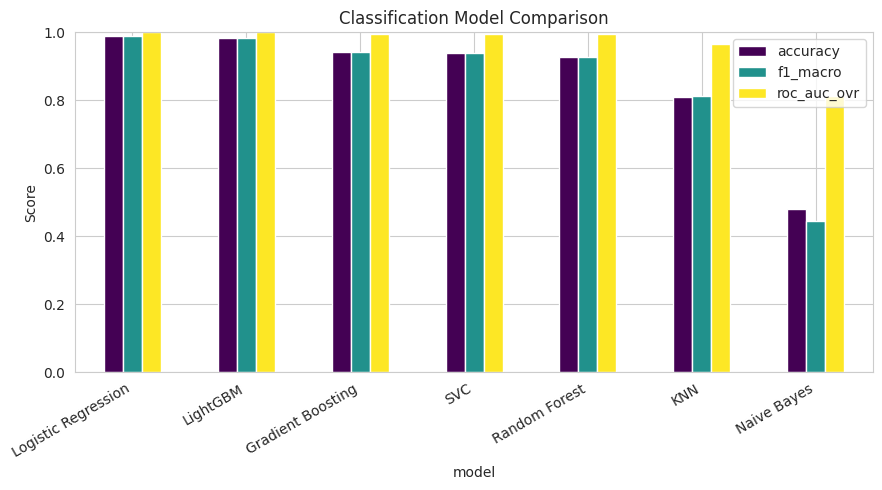

In [72]:
fig, ax = plt.subplots(figsize=(9, 5))
clf_results_df[['accuracy', 'f1_macro', 'roc_auc_ovr']].plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Classification Model Comparison')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [73]:
best_clf_name = clf_results_df.index[0]
best_clf_pipeline = clf_fitted_pipelines[best_clf_name]
print(f"Best classification pipeline: {best_clf_name}")
print(classification_report(y_clf_test_enc, clf_predictions[best_clf_name],
target_names=label_encoder.classes_))

Best classification pipeline: Logistic Regression
              precision    recall  f1-score   support

       Bin 1       0.99      0.99      0.99      1904
       Bin 2       0.98      0.99      0.99      1948
       Bin 3       0.98      0.99      0.98      1857
       Bin 4       0.99      0.99      0.99      1908
       Bin 5       1.00      1.00      1.00      1898

    accuracy                           0.99      9515
   macro avg       0.99      0.99      0.99      9515
weighted avg       0.99      0.99      0.99      9515



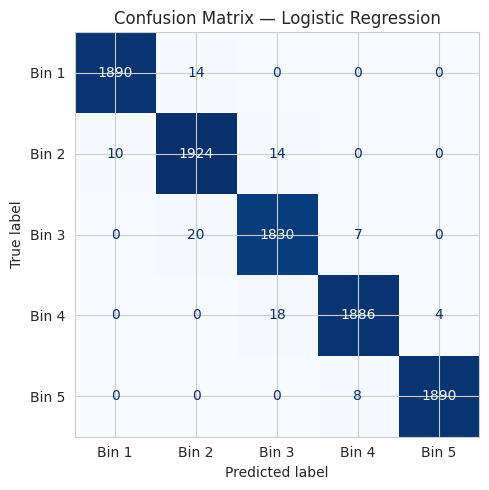

In [74]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_clf_test_enc, clf_predictions[best_clf_name])
ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_clf_name}')
plt.tight_layout()
plt.show()

## 5.4  Feature importance (best tree-based model, for interpretability)

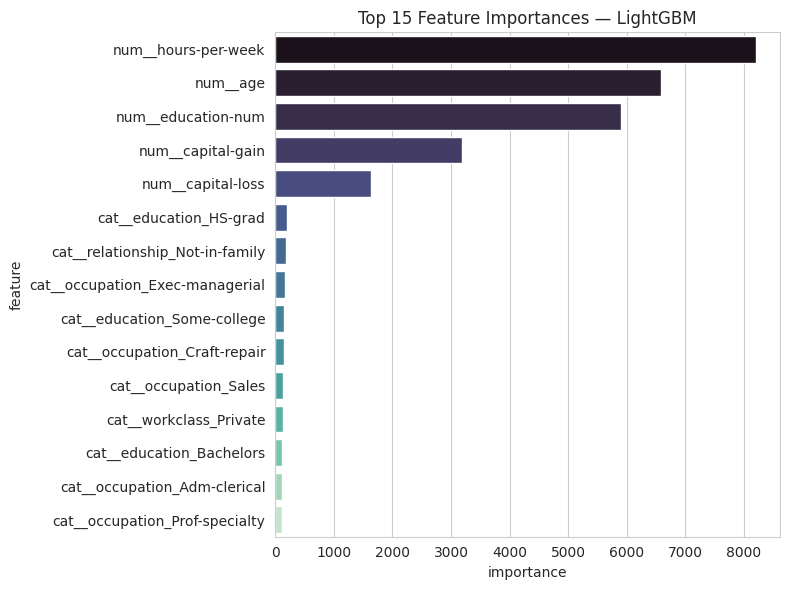

In [75]:
tree_based_candidates = ['LightGBM', 'Random Forest', 'Gradient Boosting']
importance_source = next((m for m in tree_based_candidates if m in clf_fitted_pipelines), None)
if importance_source is not None:
    fi_pipeline = clf_fitted_pipelines[importance_source]
    feature_names = fi_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = fi_pipeline.named_steps['classifier'].feature_importances_

    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi_df, x='importance', y='feature', hue='feature', palette='mako', legend=False)
    plt.title(f'Top 15 Feature Importances — {importance_source}')
    plt.tight_layout()
    plt.show()

# Cell 6 — Regression Pipelines (Car Price Prediction)

## 6.1  A leakage-safe transformer for high-cardinality categoricals

In [76]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_freq=15):
        self.min_freq = min_freq

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.frequent_ = {
            col: set(X[col].value_counts().loc[lambda s: s >= self.min_freq].index)
            for col in X.columns
        }
        return self
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            allowed = self.frequent_.get(col, set())
            X[col] = X[col].where(X[col].isin(allowed), other='Other')
        return X.values
    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)
print("RareCategoryGrouper defined.")

RareCategoryGrouper defined.


# 6.2  ColumnTransformers for regression

In [77]:
numeric_transformer_standard = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),])

numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),])

categorical_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('rare_group', RareCategoryGrouper(min_freq=15)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),])

preprocessor_reg_standard = ColumnTransformer(transformers=[
    ('num', numeric_transformer_standard, numeric_features_reg),
    ('cat', categorical_transformer_reg, categorical_features_reg),])
preprocessor_reg_poly = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly, numeric_features_reg),
    ('cat', categorical_transformer_reg, categorical_features_reg),])
print("Regression ColumnTransformers ready.")
print(f"Post-encoding feature count (standard): "
      f"{preprocessor_reg_standard.fit_transform(X_reg_train).shape[1]}")

Regression ColumnTransformers ready.
Post-encoding feature count (standard): 206


### 6.3  Regression pipelines

In [78]:
cv_reg = KFold(n_splits=3, shuffle=True, random_state=42)

In [79]:
def subsample_reg(X, y, n, seed=42):
    if len(X) <= n:
        return X, y
    idx = np.random.RandomState(seed).choice(len(X), size=n, replace=False)
    return X.iloc[idx], y.iloc[idx]

In [80]:
def tune_and_evaluate_regressor(name, pipeline, param_grid,search_sample_size=None,final_fit_sample_size=None):
    X_search, y_search = (subsample_reg(X_reg_train, y_reg_train, search_sample_size)
        if search_sample_size else (X_reg_train, y_reg_train))
    grid = GridSearchCV(pipeline, param_grid, cv=cv_reg, scoring='r2', n_jobs=-1) if param_grid \
        else _NoSearch(pipeline)
    if param_grid:
        grid.fit(X_search, y_search)
        best_pipeline = grid.best_estimator_
        best_params = grid.best_params_
    else:
        best_pipeline = pipeline
        best_params = {}
    X_fit, y_fit = (subsample_reg(X_reg_train, y_reg_train, final_fit_sample_size, seed=7)
        if final_fit_sample_size else (X_reg_train, y_reg_train))
    best_pipeline.fit(X_fit, y_fit)
    y_pred = best_pipeline.predict(X_reg_test)
    metrics = {
        'model': name,
        'best_params': best_params,
        'r2': r2_score(y_reg_test, y_pred),
        'rmse': mean_squared_error(y_reg_test, y_pred) ** 0.5,
        'mae': mean_absolute_error(y_reg_test, y_pred),}
    return best_pipeline, y_pred, metrics

In [81]:
class _NoSearch:
    def __init__(self, pipeline):
        self.pipeline = pipeline
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        self.best_estimator_ = self.pipeline
        self.best_params_ = {}
        return self

In [82]:
regression_pipelines = {
    'Linear Regression': (Pipeline([('preprocessor', preprocessor_reg_standard), ('regressor', LinearRegression())]),{},{},),

    'Polynomial Regression': (Pipeline([('preprocessor', preprocessor_reg_poly), ('regressor', LinearRegression())]),{},{},),

    'KNN Regressor': (Pipeline([
            ('preprocessor', preprocessor_reg_standard),
            ('pca', PCA(n_components=0.9, svd_solver='full', random_state=42)),
            ('regressor', KNeighborsRegressor()),]),{'regressor__n_neighbors': [5, 10, 15]},{},),
    'SVR': (Pipeline([
            ('preprocessor', preprocessor_reg_standard),
            ('pca', PCA(n_components=0.9, svd_solver='full', random_state=42)),
            ('regressor', SVR()),]),{'regressor__C': [1, 10], 'regressor__kernel': ['rbf']},
            {'search_sample_size': 3000, 'final_fit_sample_size': 6000},),
    'Random Forest Regressor': ( Pipeline([
            ('preprocessor', preprocessor_reg_standard),
            ('regressor', RandomForestRegressor(random_state=42, n_jobs=1, max_depth=15, n_estimators=150)),]),
            {'regressor__min_samples_leaf': [1, 3]},{},),
    'Gradient Boosting Regressor': (Pipeline([('preprocessor', preprocessor_reg_standard),
            ('regressor', GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=3)),]),
            {'regressor__learning_rate': [0.05, 0.1]},
            {'search_sample_size': 9000},),
    'LightGBM Regressor': (Pipeline([
            ('preprocessor', preprocessor_reg_standard),
            ('regressor', LGBMRegressor(random_state=42, verbosity=-1)),]),
           {'regressor__n_estimators': [200], 'regressor__num_leaves': [31, 63]},{},),}
reg_fitted_pipelines = {}
reg_predictions = {}
reg_results = []

In [83]:
for name, (pipe, grid_params, run_kwargs) in regression_pipelines.items():
    fitted, preds, metrics = tune_and_evaluate_regressor(name, pipe, grid_params, **run_kwargs)
    reg_fitted_pipelines[name] = fitted
    reg_predictions[name] = preds
    reg_results.append(metrics)
    print(f"[{name}] best_params={metrics['best_params']} | "
          f"R2={metrics['r2']:.4f} | RMSE={metrics['rmse']:,.0f} | MAE={metrics['mae']:,.0f}")

[Linear Regression] best_params={} | R2=0.7476 | RMSE=304,853 | MAE=223,939
[Polynomial Regression] best_params={} | R2=0.7634 | RMSE=295,109 | MAE=209,225
[KNN Regressor] best_params={'regressor__n_neighbors': 15} | R2=0.7036 | RMSE=330,353 | MAE=223,064
[SVR] best_params={'regressor__C': 10, 'regressor__kernel': 'rbf'} | R2=-0.0499 | RMSE=621,694 | MAE=466,486
[Random Forest Regressor] best_params={'regressor__min_samples_leaf': 1} | R2=0.8164 | RMSE=259,958 | MAE=165,404
[Gradient Boosting Regressor] best_params={'regressor__learning_rate': 0.1} | R2=0.7900 | RMSE=278,028 | MAE=192,050
[LightGBM Regressor] best_params={'regressor__n_estimators': 200, 'regressor__num_leaves': 63} | R2=0.8516 | RMSE=233,773 | MAE=148,137


In [84]:
reg_results_df = pd.DataFrame(reg_results).set_index('model').sort_values('r2', ascending=False)
reg_results_df

,best_params,r2,rmse,mae
model,,,,
LightGBM Regressor,"{'regressor__n_estimators': 200, 'regressor__n...",0.851552,233772.716452,148137.490193
Random Forest Regressor,{'regressor__min_samples_leaf': 1},0.816433,259958.462254,165404.377011
Gradient Boosting Regressor,{'regressor__learning_rate': 0.1},0.790026,278028.456863,192049.912054
Polynomial Regression,{},0.763433,295109.326981,209224.689653
Linear Regression,{},0.747553,304853.462039,223938.943915
KNN Regressor,{'regressor__n_neighbors': 15},0.703555,330353.245996,223063.547718
SVR,"{'regressor__C': 10, 'regressor__kernel': 'rbf'}",-0.049884,621694.301281,466485.770362


### 6.4  Evaluation plots + best pipeline export

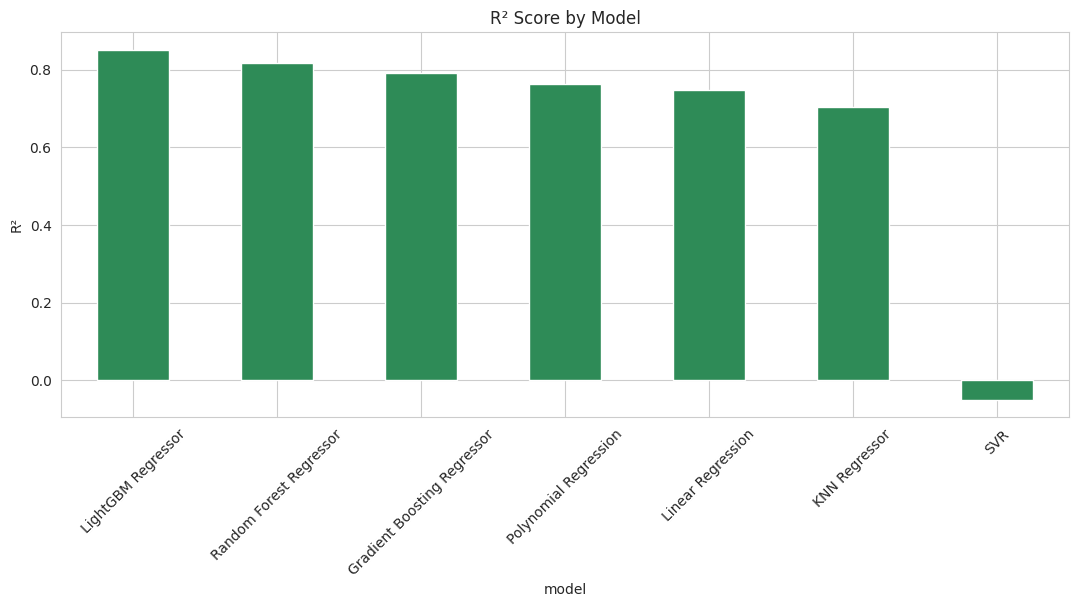

In [85]:
fig, axes = plt.subplots(figsize=(13, 5))
reg_results_df['r2'].plot(kind='bar', color='seagreen')
axes.set_title('R\u00b2 Score by Model')
axes.set_ylabel('R\u00b2')
axes.tick_params(axis='x', rotation=45)

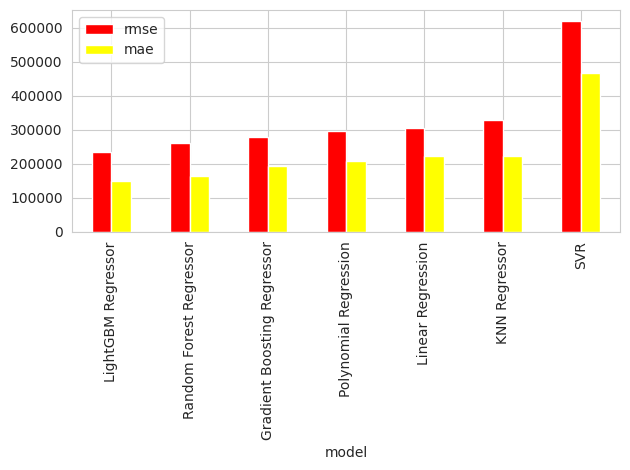

In [86]:
reg_results_df[['rmse', 'mae']].plot(kind='bar', colormap='autumn')
axes.set_title('RMSE / MAE by Model (EGP)')
axes.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [87]:
best_reg_name = reg_results_df.index[0]
best_reg_pipeline = reg_fitted_pipelines[best_reg_name]
print(f"Best regression pipeline: {best_reg_name} (R2={reg_results_df.loc[best_reg_name, 'r2']:.4f})")

Best regression pipeline: LightGBM Regressor (R2=0.8516)


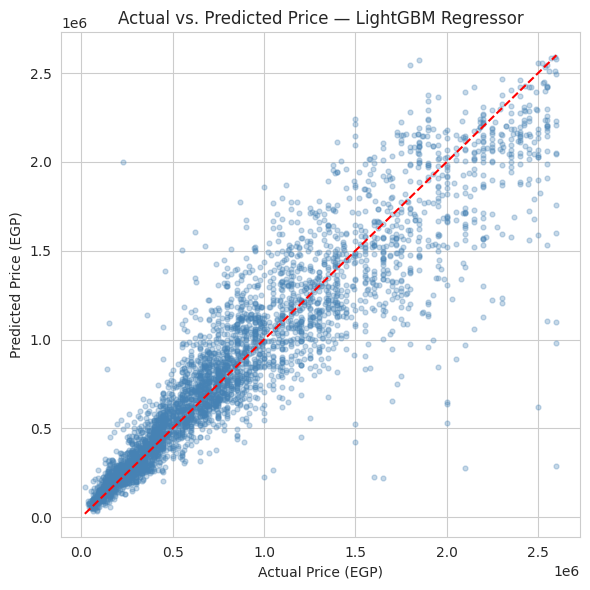

In [88]:
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, reg_predictions[best_reg_name], alpha=0.3, s=12, color='steelblue')
lims = [y_reg_test.min(), y_reg_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5)
plt.xlabel('Actual Price (EGP)')
plt.ylabel('Predicted Price (EGP)')
plt.title(f'Actual vs. Predicted Price — {best_reg_name}')
plt.tight_layout()
plt.show()

In [89]:
joblib.dump(best_clf_pipeline, 'best_income_classifier.joblib')
joblib.dump(best_reg_pipeline, 'best_car_price_regressor.joblib')
print("\nBest pipelines exported: best_income_classifier.joblib, best_car_price_regressor.joblib")


Best pipelines exported: best_income_classifier.joblib, best_car_price_regressor.joblib


## Cell 7 — Interactive Customer Recommendation & Price Prediction System

### 7.1  Build car recommendations based on predicted income tier

In [90]:
price_quantiles = car_fe['price'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values

In [91]:
tier_order = ['Bin 1', 'Bin 2', 'Bin 3', 'Bin 4', 'Bin 5']
segment_names = [
    'Economy',
    'Standard',
    'Mid-Range',
    'Premium',
    'Luxury'
]
income_to_car_recommendation = {}

In [92]:
for i, tier in enumerate(tier_order):
    lo = price_quantiles[i]
    hi = price_quantiles[i + 1]
    band_mask = ((car_fe['price'] >= lo) &(car_fe['price'] <= hi))

In [93]:
 cars_in_band = car_fe.loc[band_mask].copy()

In [94]:
   recommended_cars = (cars_in_band.sort_values('price').drop_duplicates(subset=
    ['brand','year','condition','kilo_meter']).head(10))

In [95]:
for i, tier in enumerate(tier_order):
    lo = price_quantiles[i]
    hi = price_quantiles[i + 1]
    band_mask = ((car_fe['price'] >= lo) & (car_fe['price'] <= hi))
    cars_in_band = car_fe.loc[band_mask].copy()
    recommended_cars = (cars_in_band.sort_values('price').drop_duplicates(subset=
    ['brand', 'year', 'condition', 'kilo_meter']).head(10))
    income_to_car_recommendation[tier] = {
        'segment': segment_names[i],
        'min_price': float(lo),
        'max_price': float(hi),
        'recommended_cars': recommended_cars}
print("Car recommendation system created.")

Car recommendation system created.


# 7.2  Core reusable functions

In [96]:
CLASSIFICATION_FEATURE_ORDER = list(X_clf.columns)
REGRESSION_FEATURE_ORDER = list(X_reg.columns)

In [97]:
def predict_income_tier(customer_info: dict) -> str:
    row = pd.DataFrame([
        {col: customer_info.get(col, np.nan)
        for col in CLASSIFICATION_FEATURE_ORDER}])
    pred_encoded = best_clf_pipeline.predict(row)[0]
    predicted_tier = label_encoder.inverse_transform([pred_encoded])[0]
    return predicted_tier

In [98]:
def recommend_cars_for_tier(tier: str,n_cars: int = 5) -> pd.DataFrame:
    if tier not in income_to_car_recommendation:
        raise ValueError(f"Unknown income tier: {tier}")
    cars = income_to_car_recommendation[tier]['recommended_cars'].copy()
    return cars.head(n_cars)

In [99]:
def predict_car_price(desired_car_specs: dict) -> float:
    row = pd.DataFrame([{col: desired_car_specs.get(col, np.nan)
        for col in REGRESSION_FEATURE_ORDER}])
    predicted_price = best_reg_pipeline.predict(row)[0]
    return float(predicted_price)

In [100]:
def recommend_and_predict(customer_info: dict,desired_car_specs: dict,n_cars: int = 5) -> dict:
    tier = predict_income_tier(customer_info)
    recommended_cars = recommend_cars_for_tier(tier,n_cars=n_cars)
    predicted_price = predict_car_price(desired_car_specs)
    return {
        'predicted_income_tier': tier,
        'recommended_cars': recommended_cars,
        'selected_car_specs': desired_car_specs,
        'predicted_car_price_egp': round(
            predicted_price,
            2)}

In [101]:
def print_recommended_cars(recommended_cars: pd.DataFrame) -> None:
    print("\n" + "=" * 70)
    print("                 RECOMMENDED CARS")
    print("=" * 70)
    display_columns = [
        col for col in [
            'brand',
            'model',
            'year',
            'condition',
            'kilo_meter',
            'color',
            'power_trans',
            'fuel_type',
            'location',
            'price']
        if col in recommended_cars.columns
    ]

    display(recommended_cars[display_columns].reset_index(drop=True))

In [102]:
def print_prediction_report(result: dict) -> None:
    print("\n" + "=" * 70)
    print("                    FINAL RESULT")
    print("=" * 70)
    print(f"Predicted income tier : "f"{result['predicted_income_tier']}")
    print("-" * 70)
    print("Selected car specifications:")
    for key, value in result['selected_car_specs'].items():
        print(f"  {key:<15}: {value}")
    print("-" * 70)
    print(f"Predicted car price   : "f"{result['predicted_car_price_egp']:,.2f} EGP")
    print("=" * 70)
print("Recommendation and prediction functions defined.")

Recommendation and prediction functions defined.


### 7.3  Interactive recommendation and prediction

In [ ]:

# ------------------------------------------------------------------
# 7.3  Interactive recommendation and prediction
# ------------------------------------------------------------------

print("=" * 70)
print("             CAR RECOMMENDATION SYSTEM")
print("=" * 70)


# ==============================================================
# STEP 1: Customer information
# ==============================================================

customer_info = {}

print("\nEnter customer information:\n")

for col in CLASSIFICATION_FEATURE_ORDER:

    value = input(f"{col}: ")

    # Convert numeric columns
    if col in [
        'age',
        'education-num',
        'capital-gain',
        'capital-loss',
        'hours-per-week'
    ]:

        if value.strip() == "":
            customer_info[col] = np.nan
        else:
            customer_info[col] = float(value)

    else:
        customer_info[col] = value


# ==============================================================
# STEP 2: Predict income tier
# ==============================================================

predicted_tier = predict_income_tier(
    customer_info
)

print("\n" + "=" * 70)
print(
    f"Predicted Income Tier: {predicted_tier}"
)
print("=" * 70)


# ==============================================================
# STEP 3: Recommend several cars
# ==============================================================

recommended_cars = recommend_cars_for_tier(
    predicted_tier,
    n_cars=5
)

print_recommended_cars(
    recommended_cars
)


# ==============================================================
# STEP 4: Customer selects a car
# ==============================================================

print("\nSelect one of the recommended cars.")

selected_index = int(
    input(
        f"Enter car number (1-{len(recommended_cars)}): "
    )
)

if not 1 <= selected_index <= len(recommended_cars):

    raise ValueError(
        "Invalid car selection."
    )


selected_car = recommended_cars.iloc[
    selected_index - 1
]


# ==============================================================
# STEP 5: Build specifications for selected car
# ==============================================================

selected_car_specs = {}

print("\nSelected car:")
print(selected_car)


print("\nYou can now enter/modify the car specifications.\n")


for col in REGRESSION_FEATURE_ORDER:

    # Use selected car value as default
    default_value = (
        selected_car[col]
        if col in selected_car.index
        else np.nan
    )

    user_value = input(
        f"{col} "
        f"[default={default_value}]: "
    )

    if user_value.strip() == "":
        selected_car_specs[col] = default_value

    else:

        if col in [
            'car_age',
            'kilo_meter'
        ]:

            selected_car_specs[col] = float(
                user_value
            )

        else:
            selected_car_specs[col] = user_value


# ==============================================================
# STEP 6: Predict continuous price
# ==============================================================

predicted_price = predict_car_price(
    selected_car_specs
)


# ==============================================================
# FINAL RESULT
# ==============================================================

final_result = {

    'predicted_income_tier':
        predicted_tier,

    'recommended_cars':
        recommended_cars,

    'selected_car_specs':
        selected_car_specs,

    'predicted_car_price_egp':
        round(predicted_price, 2)
}


print_prediction_report(
    final_result
)

             CAR RECOMMENDATION SYSTEM

Enter customer information:

age: 33
workclass: 33
education: 23
education-num: 23
marital-status: 32
occupation: 32
relationship: 23
race: 23
sex: 23
capital-gain: 23
capital-loss: 23
hours-per-week: 23
native-country: 23

Predicted Income Tier: Bin 5

                 RECOMMENDED CARS


,brand,model,year,condition,kilo_meter,color,power_trans,fuel_type,location,price
0,Hyundai,Avante,2026.0,New,0.0,White,Automatic,Gas,Nasr city,1320000
1,Kia,K3,2024.0,Used,2900.0,Silver,Automatic,Benzine,Smoha,1320000
2,MG,HS,2024.0,New,0.0,Gray,Automatic,Gas,Tagamo3 - New Cairo,1320000
3,Hyundai,Elantra,2021.0,Used,11000.0,Dark blue,Automatic,Gas,Nasr city,1320000
4,Chery,Tiggo 7 pro max,2027.0,New,0.0,Gray,Automatic,Benzine,6th of October,1320000



Select one of the recommended cars.
